# Opciones Americanas — Árbol Binomial CRR

Edgardo y Sara

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def arbol_crr(S0, K, r, T, sigma, N, option='call', style='european'):
    """
    Árbol binomial CRR para opciones europeas o americanas.

    S0     : precio inicial
    K      : strike
    r      : tasa libre de riesgo
    T      : tiempo al vencimiento en años
    sigma  : volatilidad
    N      : número de pasos
    option : 'call' o 'put'
    style  : 'european' o 'american'
    """
    dt = T / N
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1 / u
    p  = (np.exp(r * dt) - d) / (u - d)
    df = np.exp(-r * dt)   # factor de descuento por paso

    # Árbol de precios al vencimiento
    ST = np.array([S0 * (u**(N-i)) * (d**i) for i in range(N+1)])

    # Valores de la opción al vencimiento
    if option == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)

    # Inducción hacia atrás
    for step in range(N-1, -1, -1):
        S_step = np.array([S0 * (u**(step-i)) * (d**i) for i in range(step+1)])
        V_continuar = df * (p * V[:step+1] + (1-p) * V[1:step+2])
        if style == 'american':
            if option == 'call':
                V_ejercer = np.maximum(S_step - K, 0)
            else:
                V_ejercer = np.maximum(K - S_step, 0)
            V = np.maximum(V_continuar, V_ejercer)
        else:
            V = V_continuar

    return V[0]


Los parámetros corresponden a una acción con precio S₀ = $680, strike K = $700, tasa r = 4.2%, vencimiento T = 31 días y volatilidad σ = 16.87%.

In [2]:
# Parámetros
S0    = 680
K     = 700
r     = 0.042
T     = 31/365
sigma = 0.1687
N     = 100

precio_euro_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'european')
precio_amer_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'american')
precio_euro_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'european')
precio_amer_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'american')

print(f"Call europea  : ${precio_euro_call:.4f}")
print(f"Call americana: ${precio_amer_call:.4f}  (prima por ejercicio anticipado: ${precio_amer_call - precio_euro_call:.4f})")
print(f"Put europea   : ${precio_euro_put:.4f}")
print(f"Put americana : ${precio_amer_put:.4f}  (prima por ejercicio anticipado: ${precio_amer_put - precio_euro_put:.4f})")

Call europea  : $6.4979
Call americana: $6.4979  (prima por ejercicio anticipado: $0.0000)
Put europea   : $24.0053
Put americana : $24.4776  (prima por ejercicio anticipado: $0.4723)


---
## Pregunta 1: ¿Por qué el ejercicio anticipado de una call sobre un activo sin dividendos nunca es óptimo? ¿Qué cambia si el activo paga dividendos?

### Respuesta

Para una **call europea sobre un activo sin dividendos**, se puede demostrar que su precio siempre satisface:

$$C \geq S_0 - K e^{-rT}$$

Esto implica que **el valor de la call siempre supera su valor intrínseco** (S − K). ¿Por qué?

1. Valor temporal del dinero: Si ejerces hoy, pagas $K$ ahora. Si esperas, pagas $K$ al vencimiento, y ese dinero puede ganar intereses mientras tanto. Mantener la opción es como tener un "préstamo gratuito" del strike.
2. Valor de la opcionalidad (seguro): Ejercer anticipadamente elimina la protección contra caídas del precio. Si el activo cae por debajo de K después de ejercer, perdiste esa protección.
3. Nunca conviene matar la opcionalidad: Siempre es mejor *vender* la call en el mercado secundario (que cotizará por encima del valor intrínseco) que ejercerla y recibir solo el valor intrínseco.

Esto lo confirman nuestros resultados: la **prima por ejercicio anticipado de la call es $0.0000**.

### ¿Qué cambia con dividendos?

Cuando el activo paga un dividendo $D$, el precio de la acción **cae en aproximadamente $D$** en la fecha ex-dividendo. Esto tiene dos efectos:

- El tenedor de la opción **no recibe el dividendo** (solo lo recibe quien tiene la acción).
- El precio del activo cae, lo que reduce el valor intrínseco de la call después del dividendo.

Por tanto, puede ser óptimo ejercer **justo antes de la fecha ex-dividendo** si el dividendo es lo suficientemente grande como para compensar el valor temporal sacrificado. La condición aproximada es:

$$D > K(1 - e^{-r(T-t)})$$

En ese caso, la call americana vale más que la europea y el ejercicio anticipado puede ser racional.

---
## Gráfica de convergencia del árbol CRR

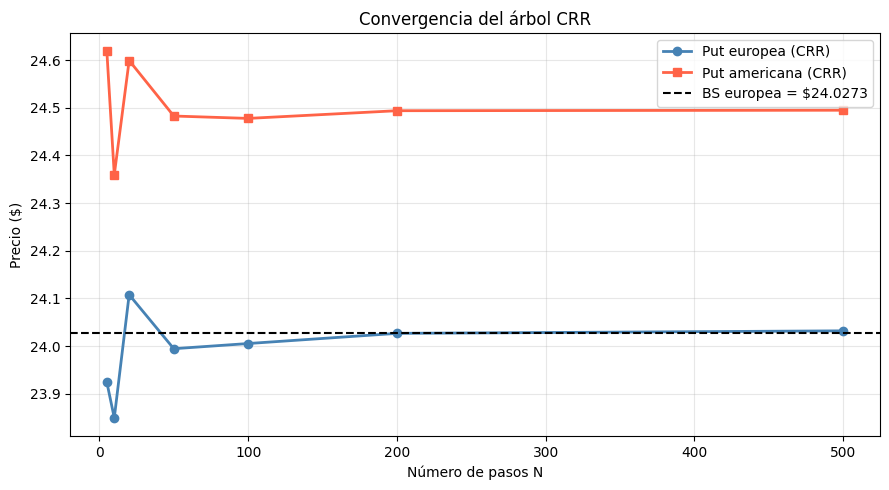

In [3]:
# Precio vs. número de pasos
pasos        = [5, 10, 20, 50, 100, 200, 500]
precios_euro = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'european') for n in pasos]
precios_amer = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'american') for n in pasos]

# Precio Black-Scholes como referencia
d1    = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2    = d1 - sigma*np.sqrt(T)
bs_put = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

plt.figure(figsize=(9, 5))
plt.plot(pasos, precios_euro, marker='o', color='steelblue',
         linewidth=2, label='Put europea (CRR)')
plt.plot(pasos, precios_amer, marker='s', color='tomato',
         linewidth=2, label='Put americana (CRR)')
plt.axhline(bs_put, color='black', linestyle='--',
            label=f'BS europea = ${bs_put:.4f}')
plt.xlabel('Número de pasos N')
plt.ylabel('Precio ($)')
plt.title('Convergencia del árbol CRR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### Pregunta 2: ¿Por qué el precio oscila antes de converger? ¿Qué relación tiene eso con si N es par o impar?


El árbol CRR oscila antes de converger porque la estructura discreta del árbol coloca los nodos en posiciones distintas relativas al strike $K$ dependiendo de si $N$ es par o impar.

En el árbol CRR, los precios terminales son $S_0 \cdot u^{N-2i}$ para $i = 0, 1, \ldots, N$. El nodo central (el que más peso tiene en la distribución) es:
- Con N par: hay un nodo exactamente en $S_0$ (precio inicial, potencialmente cercano al strike).
- Con N impar: los dos nodos centrales están en $S_0 \cdot u$ y $S_0 \cdot d$, flanqueando a $S_0$.

Esto significa que la posición del strike relativa a los nodos alterna con la paridad de N:

- Si el strike cae entre dos nodos (N impar), el árbol puede sobre o subestimar el payoff.
- Si el strike cae sobre un nodo o es capturado con mayor precisión (N par), la aproximación mejora.

Este efecto produce la **oscilación par-impar** visible en la gráfica: los valores con N par tienden a acercarse más al precio BS que los de N impar (o viceversa), alternando sistemáticamente. A medida que N crece, los nodos se vuelven más densos y la diferencia entre par e impar se vuelve insignificante, logrando la convergencia.

En resumen la oscilación es una consecuencia de la discretización del espacio de precios, no de un error del modelo. Es un artefacto numérico que desaparece con N grande.

---
## Gráfica: Prima por ejercicio anticipado vs. Strike

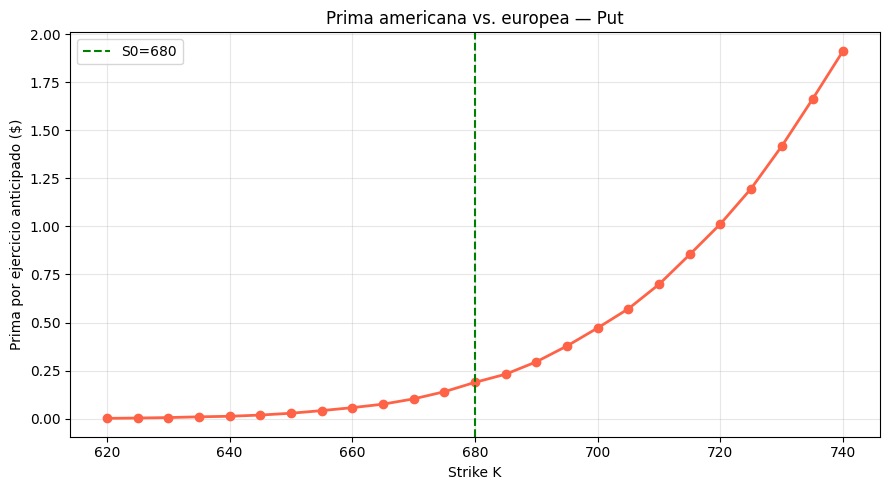

In [4]:
K_range     = np.arange(620, 741, 5)
prima_antic = []

for k in K_range:
    euro = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'european')
    amer = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'american')
    prima_antic.append(amer - euro)

plt.figure(figsize=(9, 5))
plt.plot(K_range, prima_antic, color='tomato', linewidth=2, marker='o')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Strike K')
plt.ylabel('Prima por ejercicio anticipado ($)')
plt.title('Prima americana vs. europea — Put')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Pregunta 3: ¿Por qué intuitivamente tiene sentido ejercer anticipadamente una put muy ITM?

### Respuesta

Una put muy In-The-Money (ITM) significa que el strike $K$ es mucho mayor que el precio actual del activo $S$. En ese caso:

1. **El valor intrínseco es muy alto**: el payoff inmediato $K - S$ ya es grande. Mantener la opción no puede añadir mucho más valor porque el precio de la acción **ya no puede caer más allá de cero** (el límite inferior del activo es $S \geq 0$). Si $K$ es grande y $S$ es pequeño, el upside adicional de esperar es limitado.

2. Costo de oportunidad del tiempo: Al ejercer la put hoy, recibes $K - S$ inmediatamente y puedes invertir ese efectivo a la tasa libre de riesgo $r$. Si esperas, ese dinero no está trabajando para ti.

3. La opcionalidad pierde valor: Para una put muy ITM, la probabilidad de que el activo suba lo suficiente como para que la opción expire OTM es muy baja. La "protección" que ofrece esperar vale poco porque ya estás muy protegido.

4. Comparación matemática: El valor de continuar es $e^{-r \, dt}[p \cdot V_u + (1-p) \cdot V_d]$. Para una put muy ITM, el incremento esperado del valor de la opción al esperar no compensa el costo de descontar ese flujo. El árbol reconoce esto cuando `V_ejercer > V_continuar`.

Por esto, en la gráfica, la prima por ejercicio anticipado es **mayor para strikes altos** (puts profundamente ITM), y se acerca a cero cuando la put está OTM (K < S₀), donde el ejercicio anticipado nunca tiene sentido.

---
## Pregunta 4: Si modificas T a 31 días y luego a 1 año, ¿cómo esperas que cambie la diferencia entre la put americana y la europea?

In [5]:
# Comparación T = 31 días vs T = 1 año
for T_test, label in [(31/365, '31 días'), (1.0, '1 año')]:
    euro = arbol_crr(S0, K, r, T_test, sigma, 200, 'put', 'european')
    amer = arbol_crr(S0, K, r, T_test, sigma, 200, 'put', 'american')
    print(f"T = {label:>7s} | Put europea: ${euro:.4f} | Put americana: ${amer:.4f} | Prima anticipada: ${amer - euro:.4f}")

T = 31 días | Put europea: $24.0267 | Put americana: $24.4937 | Prima anticipada: $0.4671
T =   1 año | Put europea: $41.1686 | Put americana: $45.2528 | Prima anticipada: $4.0842




Al extender el plazo de vencimiento, la prima por ejercicio anticipado de la put americana aumenta, y el resultado numérico lo confirma.

**¿Por qué?** Hay dos fuerzas en juego:

| Factor | T corto (31 días) | T largo (1 año) |
|--------|-------------------|------------------|
| Costo de oportunidad acumulado | Pequeño (poco tiempo para ganar intereses) | Grande (más tiempo para invertir el efectivo de la put) |
| Ventanas de ejercicio anticipado | Pocas | Muchas |
| Probabilidad de que el activo caiga más | Baja (poco tiempo) | Alta (más tiempo, más varianza) |
| Valor de la opcionalidad | Relativamente alto (no vale la pena ejercer pronto) | Moderado, pero el costo de oportunidad domina para puts ITM |

Con T largo, el tenedor de la put americana tiene más períodos en los que podría convenir ejercer anticipadamente. Cada paso del árbol es una oportunidad donde el árbol compara `V_continuar` vs `V_ejercer`, y con más pasos habrá más momentos en que ejercer sea óptimo.

Además, el factor de descuento acumulado $e^{-rT}$ se vuelve más pequeño con T grande, lo que hace que el valor presente de recibir $K - S$ "más tarde" sea menor que recibirlo hoy. Esto incentiva el ejercicio anticipado.

Por lo tanto a mayor plazo, mayor diferencia entre la put americana y la europea, porque hay más oportunidades y mayor costo de oportunidad.

---
## Gráfica: BS vs. CRR — Put Europea

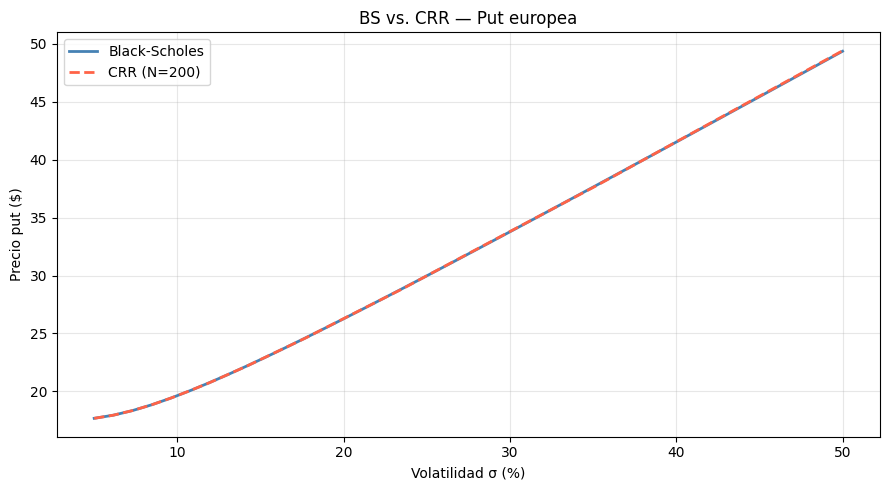

In [6]:
sigma_range = np.linspace(0.05, 0.50, 40)
bs_precios  = []
crr_precios = []

for s in sigma_range:
    d1 = (np.log(S0/K) + (r + 0.5*s**2)*T) / (s*np.sqrt(T))
    d2 = d1 - s*np.sqrt(T)
    bs_precios.append(K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1))
    crr_precios.append(arbol_crr(S0, K, r, T, s, 200, 'put', 'european'))

plt.figure(figsize=(9, 5))
plt.plot(sigma_range*100, bs_precios,  color='steelblue', linewidth=2,
         label='Black-Scholes')
plt.plot(sigma_range*100, crr_precios, color='tomato',    linewidth=2,
         linestyle='--', label='CRR (N=200)')
plt.xlabel('Volatilidad σ (%)')
plt.ylabel('Precio put ($)')
plt.title('BS vs. CRR — Put europea')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Pregunta 5: El árbol CRR usa probabilidades neutrales al riesgo p, no probabilidades reales. ¿Qué significa eso y por qué es válido para el pricing?



### ¿Qué son las probabilidades neutrales al riesgo?

En el árbol CRR, la probabilidad de subida se calcula como:

$$p = \frac{e^{r \, \Delta t} - d}{u - d}$$

Esta $p$ **no es la probabilidad real** de que el activo suba. En el mundo real, el activo puede tener cualquier rendimiento esperado $\mu \neq r$ dependiendo de su riesgo. La probabilidad real sería:

$$p_{\text{real}} = \frac{e^{\mu \, \Delta t} - d}{u - d}$$

La probabilidad neutral al riesgo $p$ es la que haría que el activo crezca en esperanza exactamente a la tasa libre de riesgo $r$:

$$E^Q[S_{t+\Delta t}] = p \cdot S \cdot u + (1-p) \cdot S \cdot d = S \cdot e^{r \Delta t}$$

### ¿Por qué es válido usarla para el pricing?

La justificación viene del **Teorema Fundamental de Valoración de Activos** y del argumento de **no arbitraje**:

1. Replicación: En el árbol binomial, cualquier opción puede ser **perfectamente replicada** con una cartera de la acción y el bono libre de riesgo. El precio de la opción es el costo de armar esa cartera replicante.

2. El precio no depende de las preferencias: Como la opción se puede replicar, su precio debe ser el mismo para cualquier inversionista, independientemente de su aversión al riesgo o sus expectativas sobre el retorno futuro $\mu$.

3. Cambio de medida: Matemáticamente, cambiar de la probabilidad real $P$ a la medida neutral al riesgo $Q$ es un cambio de medida de probabilidad (Girsanov). Bajo $Q$, todos los activos rinden $r$, lo que permite descontar flujos futuros simplemente a la tasa libre de riesgo.

4. Equivalencia: El precio calculado bajo $Q$ es idéntico al precio que obtendrías construyendo la cartera de cobertura delta-neutral bajo $P$.

En palabras simples, no importa si el mercado espera que la acción suba 20% o 5% anual; el precio de la opción está determinado por la estructura de pagos y la capacidad de cubrirse dinámicamente, no por las creencias individuales sobre el futuro. Las probabilidades neutrales al riesgo son la herramienta matemática que hace consistente este argumento de no arbitraje.